# Bandit Problem

In [268]:
# imports
from bandits import Bandit
import random
import numpy as np
import matplotlib.pyplot as plt
import math
# Include your imports here, if any are used. 

A bandit is one option (or “arm”) you can choose, where the reward you get is uncertain and must be learned by trying it out.
In multi-armed bandits, you repeatedly pick among several such uncertain options to find which one pays best.

A list of ten bandit objects initialized in the list...

In [269]:
bandits = [Bandit(random.random()*4-2) for _ in range(10)]

To generate reward from that bandit, use the pullLever() command

In [270]:
bandits[0].pullLever()

-1.0214976060266838

## Greedy algorithm Implementation

In [271]:
def run_greedy():
    # TODO: Implement the greedy algorithm here
    # Return the reward from the bandits in a list
    rewards=[]
    a=np.zeros(10)
    b=np.zeros(10)
    for k in range(10):
        a[k]=bandits[k].pullLever()
        b[k]=1
        rewards.append(a[k])
    for i in range(990):
        j=np.argmax(a)
        x=bandits[j].pullLever()
        a[j]=(a[j]*b[j] + x)/(b[j]+1)
        b[j]=b[j]+1
        rewards.append(x)
    return rewards


Plot the cumulative average of rewards as the number of iterations increases. and display that image below.

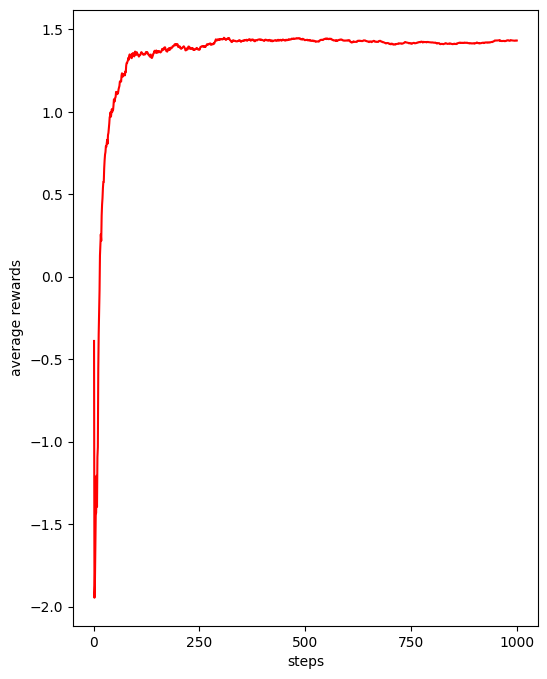

In [272]:
rewards=run_greedy()
mean_rewards=np.cumsum(rewards)/np.arange(1,len(rewards)+1)
a=np.arange(1,len(rewards)+1)
plt.figure(figsize=(6,8))
plt.xticks(np.arange(0,1001,250))
plt.yticks(np.arange(-2,2,0.5))
plt.plot(a,mean_rewards,'r-')
plt.xlabel('steps')
plt.ylabel('average rewards')
plt.show()




## $\epsilon$-greedy Algorithm

In [273]:
def run_epsilon_greedy(epsilon):
    # TODO: Implement the epsilon greedy algorithm here
    # Return the reward from the bandits in a list
    rewards=[]
    b=np.zeros(10)
    c=np.zeros(10)
    for i in range(1000):   
        if random.random()<epsilon:
           x=random.randint(0,9)
           y=bandits[x].pullLever()
           rewards.append(y)
           b[x]=(b[x]*c[x] + y)/(c[x]+1)
           c[x]=c[x]+1
        else:
           j=np.argmax(b)
           x=bandits[j].pullLever()
           rewards.append(x)
           b[j]=(b[j]*c[j] + x)/(c[j]+1)
           c[j]=c[j]+1
    return rewards

    

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

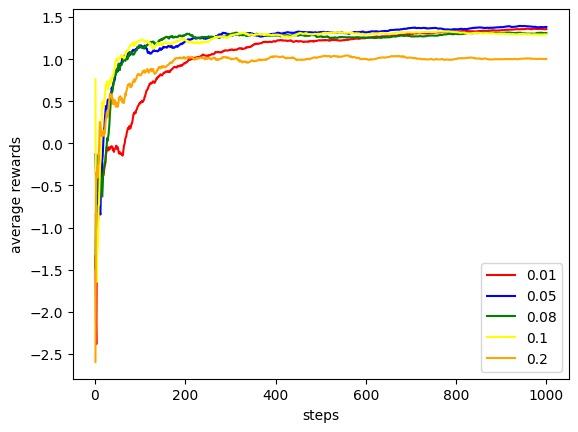

In [274]:
colours=['red','blue','green','yellow','orange']
epsilons=[0.01,0.05,0.08,0.1,0.2]
rewards=[run_epsilon_greedy(epsilons[i]) for i in range(5)]
mean_rewards=[np.cumsum(rewards[i])/np.arange(1,len(rewards[i])+1) for i in range(5)]
for i in range(5):
    a=np.arange(1,len(rewards[0])+1)
    plt.plot(a,mean_rewards[i],color=colours[i],label=f"{epsilons[i]}")
plt.xlabel('steps')
plt.ylabel('average rewards')
plt.legend()
plt.show()


## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

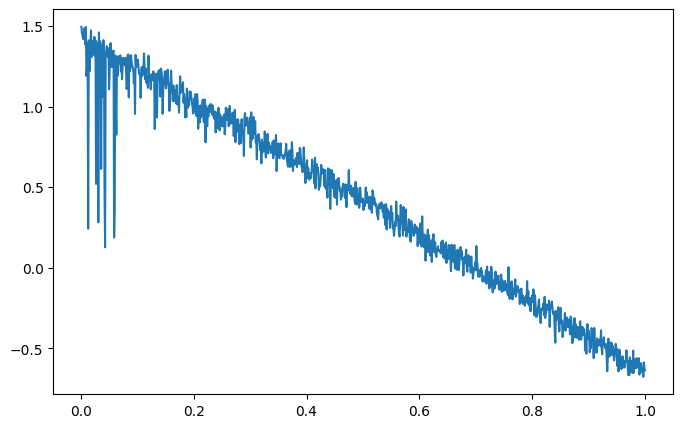

the optimal value of epsilon is 0.001


In [275]:
epsilons=[i/1000 for i in range(1,1001)]
avg_rewards=[]
for eps in epsilons:
    rewards=run_epsilon_greedy(eps)
    cumulative_avg=np.cumsum(rewards)/np.arange(1,1001)
    avg_rewards.append(cumulative_avg[-1])
plt.figure(figsize=(8,5))
plt.plot(epsilons,avg_rewards)
plt.show()
optimal_index=np.argmax(avg_rewards)
optimal_epsilon=epsilons[optimal_index]
print("the optimal value of epsilon is",optimal_epsilon)

## Optimistic Initial Values

In [276]:
def run_optimistic_greedy():
    # TODO: Implement the optimistic greedy algorithm here

    # Return the reward from the bandits in a list
    rewards=[]
    a=np.zeros(10)
    b=np.zeros(10)
    for i in range(1000):
        if(0 in b):
           x=max(a[np.argmax(a)],10.0)
           if x==10:
               index=np.where(b==0)
               y=bandits[index[0][0]].pullLever()
               rewards.append(y)
               a[index]=(a[index]*b[index] + y)/(b[index] +1)
               b[index]=b[index]+1
           else:
               index=np.argmax(a)
               y=bandits[index].pullLever()
               rewards.append(y)
               a[index]=(a[index]*b[index] + y)/(b[index] +1)
               b[index]=b[index]+1
        else:
            index=np.argmax(a)
            y=bandits[index].pullLever()
            rewards.append(y)
            a[index]=(a[index]*b[index] + y)/(b[index] +1)
            b[index]=b[index]+1
    return rewards

Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$ and try to compare which is better.

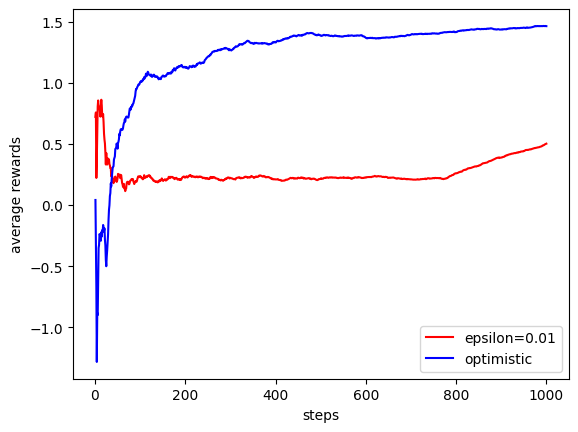

In [277]:
rewards1=run_epsilon_greedy(0.01)
mean_rewards1=np.cumsum(rewards1)/np.arange(1,len(rewards1)+1)
rewards2=run_optimistic_greedy()
mean_rewards2=np.cumsum(rewards2)/np.arange(1,len(rewards2)+1)
a=np.arange(1,len(rewards1)+1)
b=np.arange(1,len(rewards2)+1)
plt.plot(a,mean_rewards1,color='red',label=f"{'epsilon=0.01'}")
plt.plot(b,mean_rewards2,color='blue',label=f"{'optimistic'}")
plt.xlabel('steps')
plt.ylabel('average rewards')
plt.legend()
plt.show()

## Upper Confidence Bound (UCB)

In [278]:
def run_ucb(c):
    # TODO: Implement the UCB algorithm here
    # Return the reward from the bandits in a list
    rewards=[]
    a=np.zeros(10)
    b=np.zeros(10)
    d=np.zeros(10)
    for k in range(10):
        a[k]=bandits[k].pullLever()
        b[k]=1
        rewards.append(a[k])
        d[k]=a[k]+ c*math.sqrt(math.log(np.sum(b))/b[k])
    for i in range(990):
        x=np.argmax(d)
        z=bandits[x].pullLever()
        rewards.append(z)
        a[x]=(a[x]*b[x] + z)/(b[x]+1)
        d[x]=a[x] + c*math.sqrt(math.log(np.sum(b))/b[x]+1)
        b[x]=b[x]+1
    return rewards

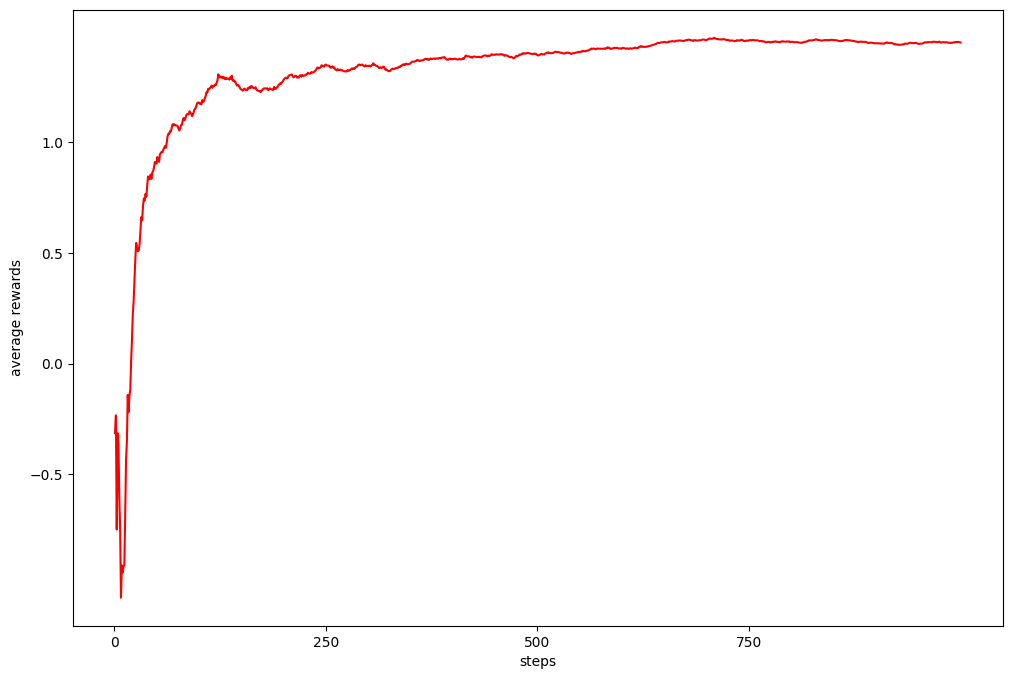

In [279]:
rewards=run_ucb(2)
mean_rewards=np.cumsum(rewards)/np.arange(1,len(rewards)+1)
a=np.arange(1,len(rewards)+1)
plt.figure(figsize=(12,8))
plt.xticks(np.arange(0,1000,250))
plt.yticks(np.arange(-0.5,1.5,0.5))
plt.plot(a,mean_rewards,'r-')
plt.xlabel('steps')
plt.ylabel('average rewards')
plt.show()



